<a href="https://colab.research.google.com/github/Monasri29-hub/Delivery-Delay-Risk/blob/main/Delivery_delay_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv(r"/content/dataset_09_delivery_delay_risk.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   distance_km         1000 non-null   float64
 1   warehouse_load      1000 non-null   int64  
 2   order_hour          1000 non-null   int64  
 3   items_count         1000 non-null   int64  
 4   weather_risk        1000 non-null   int64  
 5   carrier_delay_rate  1000 non-null   float64
 6   target              1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


,distance_km,warehouse_load,order_hour,items_count,weather_risk,carrier_delay_rate,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,29.578510,3.085000,2.913000,2.962000,2.946000,50.068690,0.50000
std,21.943768,1.754096,1.711245,1.751463,1.439846,19.974937,0.50025
min,3.410000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000
25%,14.807500,2.000000,2.000000,2.000000,2.000000,35.387500,0.00000
50%,23.765000,3.000000,3.000000,3.000000,3.000000,50.470000,0.50000
75%,36.730000,4.000000,4.000000,4.000000,4.000000,63.567500,1.00000
max,162.000000,12.000000,10.000000,9.000000,5.000000,100.000000,1.00000


In [ ]:
# Check nulls
df.isnull().sum()

# Drop duplicates
df = df.drop_duplicates()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.685

Confusion Matrix:
[[64 24]
 [39 73]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67        88
           1       0.75      0.65      0.70       112

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.68       200
weighted avg       0.69      0.69      0.69       200



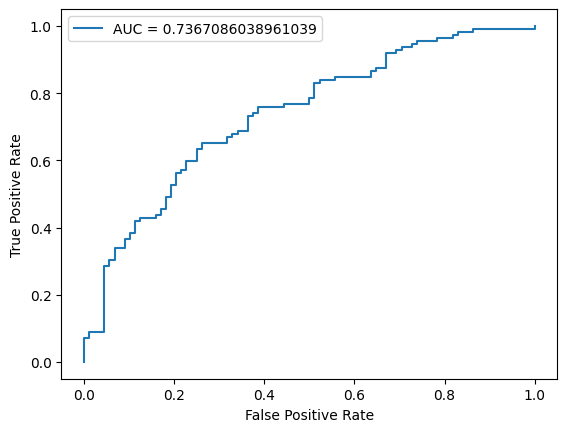

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": df.drop("target", axis=1).columns,
    "Importance": model.coef_[0]
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
5,carrier_delay_rate,0.600944
3,items_count,0.530557
1,warehouse_load,0.518433
4,weather_risk,-0.240849
2,order_hour,-0.311993
0,distance_km,-0.330874
